<a href="https://colab.research.google.com/github/AhsanDz/4-Ahsan/blob/main/EDA_Ahsan.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

##Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

##Initial EDA

###Read File & Data Info

In [2]:
df = pd.read_csv('US_Accidents.csv')

pd.set_option('display.max_columns', None)
df.head()

,ID,Source,Severity,Start_Time,End_Time,Start_Lat,Start_Lng,End_Lat,End_Lng,Distance(mi),Description,Street,City,County,State,Zipcode,Country,Timezone,Airport_Code,Weather_Timestamp,Temperature(F),Wind_Chill(F),Humidity(%),Pressure(in),Visibility(mi),Wind_Direction,Wind_Speed(mph),Precipitation(in),Weather_Condition,Amenity,Bump,Crossing,Give_Way,Junction,No_Exit,Railway,Roundabout,Station,Stop,Traffic_Calming,Traffic_Signal,Turning_Loop,Sunrise_Sunset,Civil_Twilight,Nautical_Twilight,Astronomical_Twilight
0,A-2047758,Source2,2,2019-06-12 10:10:56,2019-06-12 10:55:58,30.641211,-91.153481,NaN,NaN,0.000,Accident on LA-19 Baker-Zachary Hwy at Lower Z...,Highway 19,Zachary,East Baton Rouge,LA,70791-4610,US,US/Central,KBTR,2019-06-12 09:53:00,77.0,77.0,62.0,29.92,10.0,NW,5.0,0.0,Fair,False,False,False,False,False,False,False,False,False,False,False,True,False,Day,Day,Day,Day
1,A-4694324,Source1,2,2022-12-03 23:37:14.000000000,2022-12-04 01:56:53.000000000,38.990562,-77.399070,38.990037,-77.398282,0.056,Incident on FOREST RIDGE DR near PEPPERIDGE PL...,Forest Ridge Dr,Sterling,Loudoun,VA,20164-2813,US,US/Eastern,KIAD,2022-12-03 23:52:00,45.0,43.0,48.0,29.91,10.0,W,5.0,0.0,Fair,False,False,False,False,False,False,False,False,False,False,False,False,False,Night,Night,Night,Night
2,A-5006183,Source1,2,2022-08-20 13:13:00.000000000,2022-08-20 15:22:45.000000000,34.661189,-120.492822,34.661189,-120.492442,0.022,Accident on W Central Ave from Floradale Ave t...,Floradale Ave,Lompoc,Santa Barbara,CA,93436,US,US/Pacific,KLPC,2022-08-20 12:56:00,68.0,68.0,73.0,29.79,10.0,W,13.0,0.0,Fair,False,False,False,False,False,False,False,False,False,False,False,True,False,Day,Day,Day,Day
3,A-4237356,Source1,2,2022-02-21 17:43:04,2022-02-21 19:43:23,43.680592,-92.993317,43.680574,-92.972223,1.054,Incident on I-90 EB near REST AREA Drive with ...,14th St NW,Austin,Mower,MN,55912,US,US/Central,KAUM,2022-02-21 17:35:00,27.0,15.0,86.0,28.49,10.0,ENE,15.0,0.0,Wintry Mix,False,False,False,False,False,False,False,False,False,False,False,False,False,Day,Day,Day,Day
4,A-6690583,Source1,2,2020-12-04 01:46:00,2020-12-04 04:13:09,35.395484,-118.985176,35.395476,-118.985995,0.046,RP ADV THEY LOCATED SUSP VEH OF 20002 - 726 CR...,River Blvd,Bakersfield,Kern,CA,93305-2649,US,US/Pacific,KBFL,2020-12-04 01:54:00,42.0,42.0,34.0,29.77,10.0,CALM,0.0,0.0,Fair,False,False,False,False,False,False,False,False,False,False,False,False,False,Night,Night,Night,Night


In [3]:
df.shape

(500000, 46)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500000 entries, 0 to 499999
Data columns (total 46 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   ID                     500000 non-null  object 
 1   Source                 500000 non-null  object 
 2   Severity               500000 non-null  int64  
 3   Start_Time             500000 non-null  object 
 4   End_Time               500000 non-null  object 
 5   Start_Lat              500000 non-null  float64
 6   Start_Lng              500000 non-null  float64
 7   End_Lat                279623 non-null  float64
 8   End_Lng                279623 non-null  float64
 9   Distance(mi)           500000 non-null  float64
 10  Description            499999 non-null  object 
 11  Street                 499309 non-null  object 
 12  City                   499981 non-null  object 
 13  County                 500000 non-null  object 
 14  State                  500000 non-nu

###Cek Missing Values

In [5]:
# Menghitung persentase missing values tiap kolom, diurutkan dari yang terbesar
missing_percentages = df.isnull().sum().sort_values(ascending=False) / len(df) * 100
print(missing_percentages[missing_percentages > 0])

End_Lng                  44.0754
End_Lat                  44.0754
Precipitation(in)        28.5232
Wind_Chill(F)            25.8034
Wind_Speed(mph)           7.3974
Visibility(mi)            2.2582
Wind_Direction            2.2394
Humidity(%)               2.2260
Weather_Condition         2.2202
Temperature(F)            2.0932
Pressure(in)              1.7856
Weather_Timestamp         1.5348
Sunrise_Sunset            0.2966
Civil_Twilight            0.2966
Astronomical_Twilight     0.2966
Nautical_Twilight         0.2966
Airport_Code              0.2892
Street                    0.1382
Timezone                  0.1014
Zipcode                   0.0232
City                      0.0038
Description               0.0002
dtype: float64


/tmp/ipykernel_45782/1847255438.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_missing.values, y=top_missing.index, palette='Reds_r')
/tmp/ipykernel_45782/1847255438.py:10: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


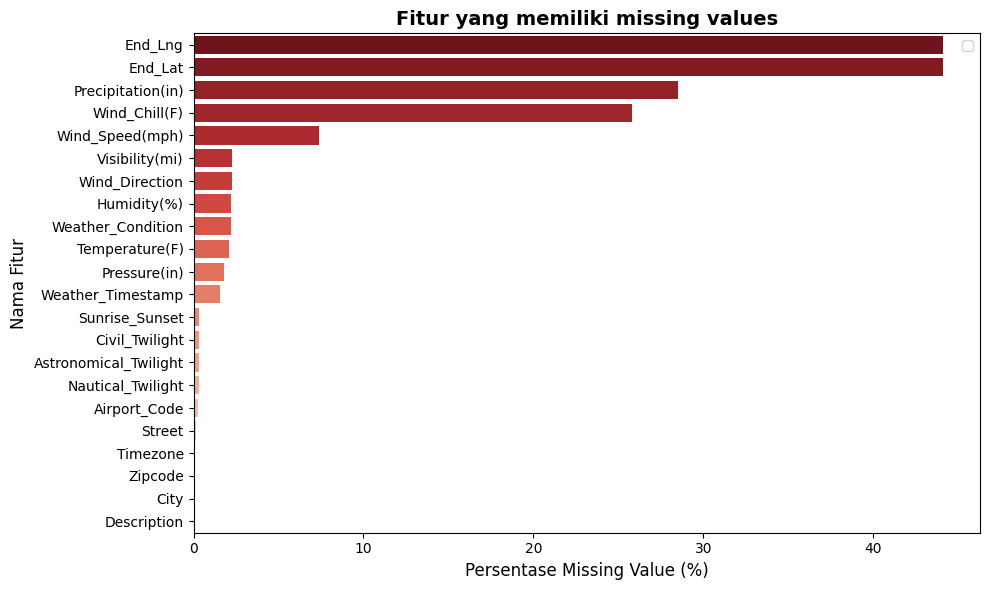

In [6]:
#Visual
top_missing = missing_percentages[missing_percentages > 0]

plt.figure(figsize=(10, 6))
sns.barplot(x=top_missing.values, y=top_missing.index, palette='Reds_r')

plt.title('Fitur yang memiliki missing values', fontsize=14, fontweight='bold')
plt.xlabel('Persentase Missing Value (%)', fontsize=12)
plt.ylabel('Nama Fitur', fontsize=12)
plt.legend()
plt.tight_layout()
plt.show()

Karena kolom End_Lng dan End_Lat hampir 50% tidak memiliki nilai, maka kolom tersebut kemungkinan besar akan didrop.
Sedangkan, untuk yang lainnya bisa diimputasi

### Cek Distribusi beberapa Variabel yang Penting

#### Target

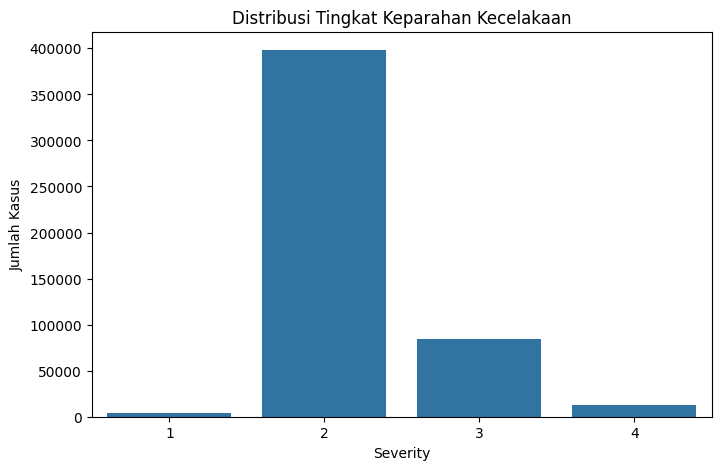

In [7]:
plt.figure(figsize=(8,5))
sns.countplot(x="Severity", data=df)

plt.title("Distribusi Tingkat Keparahan Kecelakaan")
plt.xlabel("Severity")
plt.ylabel("Jumlah Kasus")

plt.show()

In [8]:
df['Severity'].value_counts(normalize=True) * 100

,proportion
Severity,
2,79.6284
3,16.9040
4,2.6128
1,0.8548


Data target sangat Imbalanced. Tingkat keparahan 2 mendominasi hingga hampir 80%, sementara tingkat 1 di bawah 1%.

#### Numerical

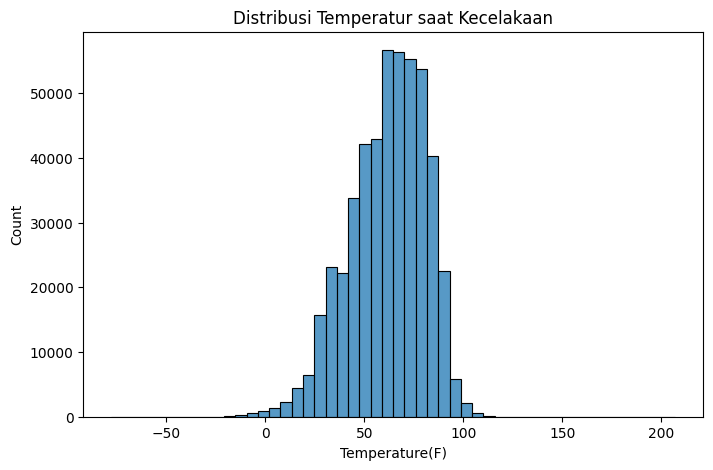

In [9]:
plt.figure(figsize=(8,5))
sns.histplot(df["Temperature(F)"], bins=50)

plt.title("Distribusi Temperatur saat Kecelakaan")
plt.show()

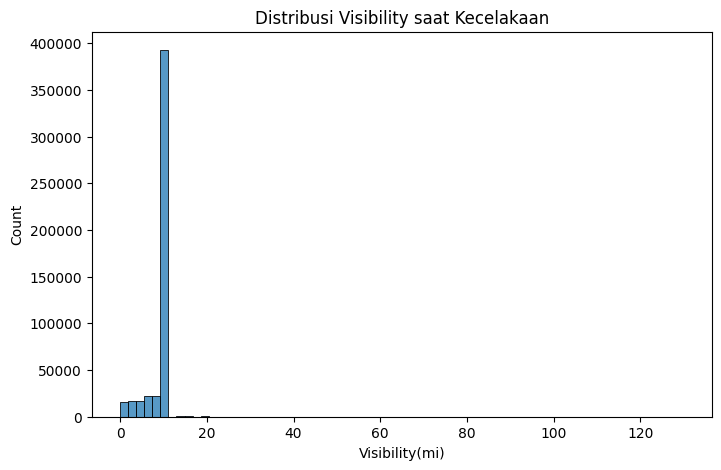

In [10]:
plt.figure(figsize=(8,5))
sns.histplot(df["Visibility(mi)"], bins=70)

plt.title("Distribusi Visibility saat Kecelakaan")
plt.show()

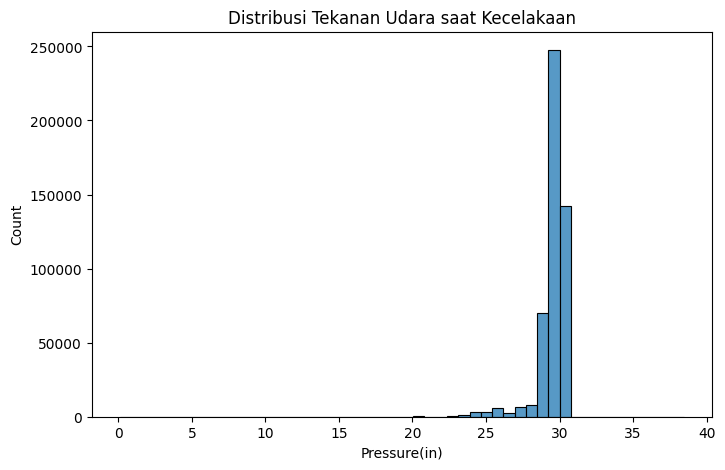

In [11]:
plt.figure(figsize=(8,5))
sns.histplot(df["Pressure(in)"], bins=50)

plt.title("Distribusi Tekanan Udara saat Kecelakaan")
plt.show()

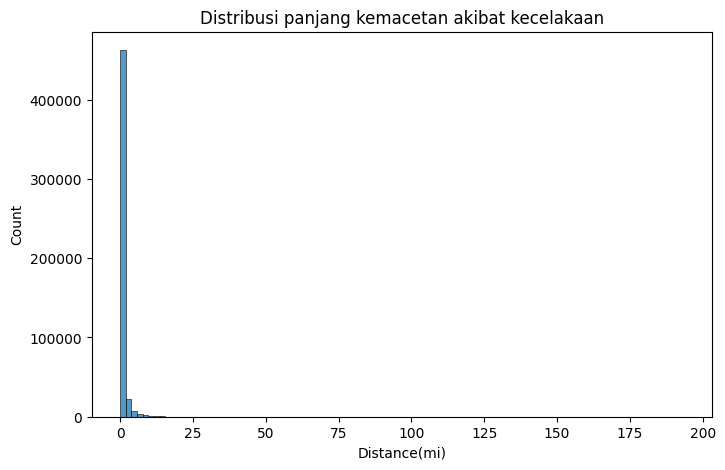

In [12]:
plt.figure(figsize=(8,5))
sns.histplot(df["Distance(mi)"], bins=100)

plt.title("Distribusi panjang kemacetan akibat kecelakaan")
plt.show()

#### Kategorikal

<Axes: xlabel='Weather_Condition'>

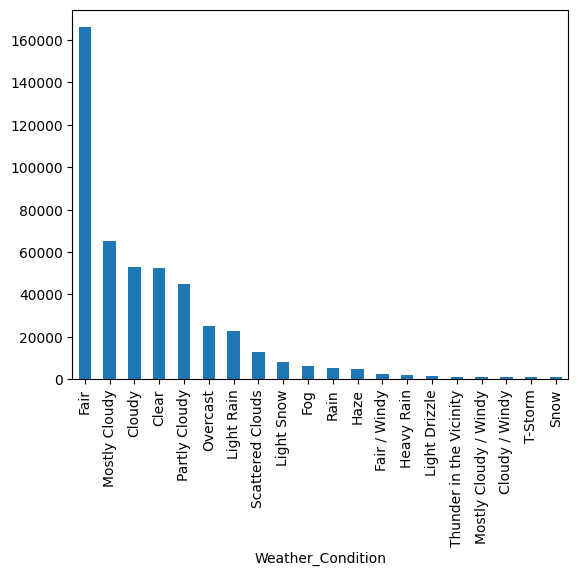

In [13]:
df["Weather_Condition"].value_counts().head(20).plot(kind="bar")

<Axes: xlabel='Sunrise_Sunset', ylabel='count'>

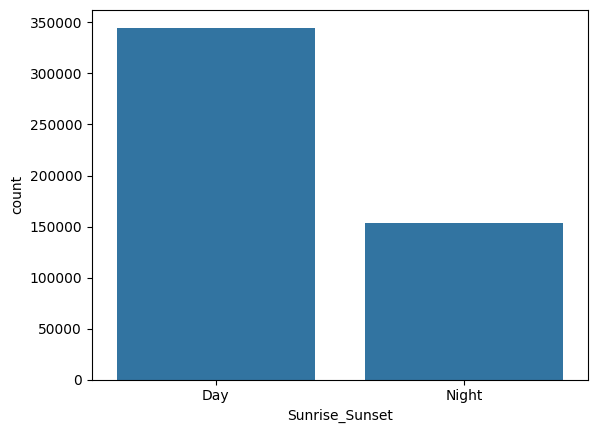

In [14]:
sns.countplot(x="Sunrise_Sunset", data=df)

## Data Cleaning

### Menghapus kolom yang tidak relevan

In [15]:
drop_columns = [
    "ID",
    "Description",
    "Street",
    "Zipcode",
    "Country",
    "Airport_Code",
    "Timezone",
    "Weather_Timestamp"
]

df = df.drop(columns=drop_columns)

### Menangani Missing Value

Menhapus kolom End_Lat End_Lng karena terlalu banyak missing value dan tidak terlalu penting. Wind_Chill juga dihapus karena banyak missing dan redundant dengan temperature.

In [16]:
drop_cols = [
    "End_Lat",
    "End_Lng",
    "Wind_Chill(F)"
]

df = df.drop(columns=drop_cols)

Jika data curah hujan tidak tersedia, kami mengasumsikan kondisi tidak hujan sehingga nilai diisi dengan nol.

In [17]:
df["Precipitation(in)"] = df["Precipitation(in)"].fillna(0)

Kolom numerik yang memiliki missing value, diisi menggunakan median karena lebih stabil terhadap outlier dibanding mean.

In [18]:
numeric_cols = [
    "Temperature(F)",
    "Visibility(mi)",
    "Wind_Speed(mph)",
    "Pressure(in)",
    "Humidity(%)"
]

for col in numeric_cols:
    df[col] = df[col].fillna(df[col].median())

Untuk variabel kategori, data yang kosong diganti dengan kategori yang paling sering muncul agar representatif terhadap kondisi umum pada dataset.

In [19]:
categorical_cols = [
    "Weather_Condition",
    "Wind_Direction",
    "Sunrise_Sunset",
    "Civil_Twilight",
    "Nautical_Twilight",
    "Astronomical_Twilight",
    "City"
]

for col in categorical_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

cek kembali missing value

In [20]:
missing_after = df.isnull().sum()
missing_after[missing_after > 0]

,0


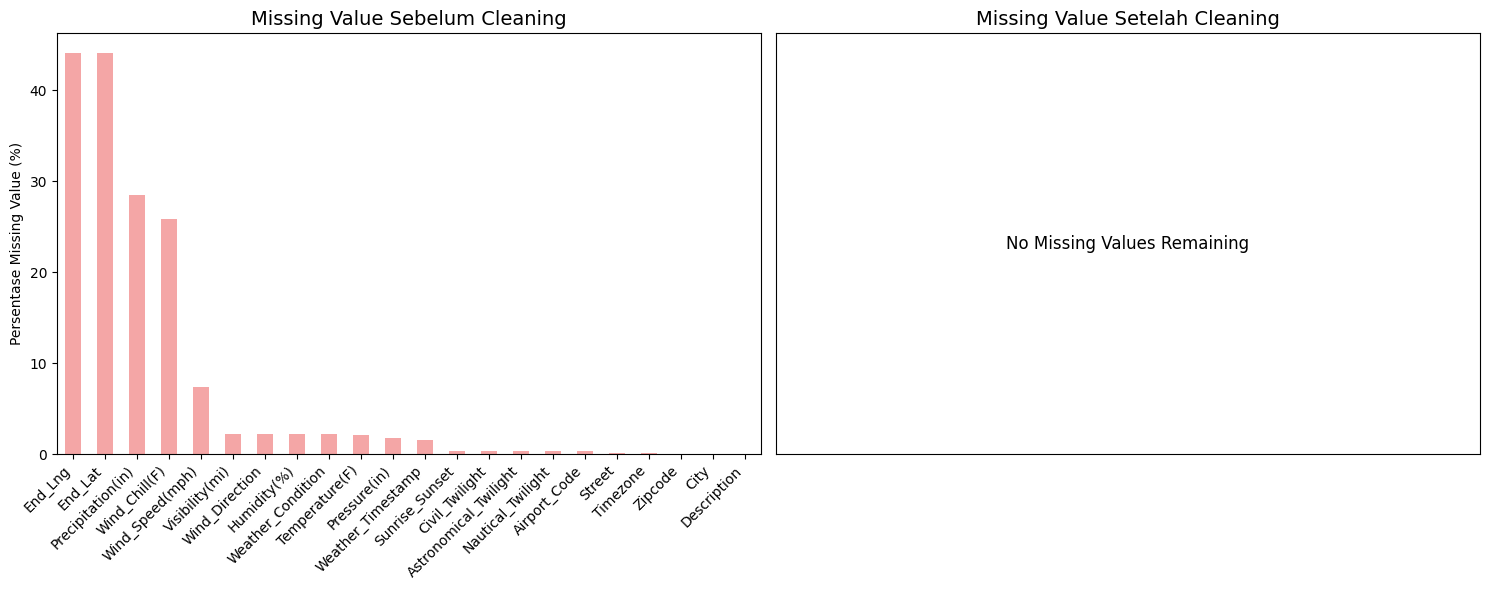

In [22]:
missing_before = missing_percentages
missing_after_filtered = df.isnull().sum()/len(df)*100

plt.figure(figsize=(15, 6))

plt.subplot(1, 2, 1) # 1 row, 2 columns, first plot
missing_before[missing_before > 0].plot(kind="bar", alpha=0.7, color='lightcoral')
plt.title("Missing Value Sebelum Cleaning", fontsize=14)
plt.ylabel("Persentase Missing Value (%)")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()

plt.subplot(1, 2, 2) # 1 row, 2 columns, second plot
# Check if there are any missing values remaining after filtering
if not missing_after_filtered[missing_after_filtered > 0].empty:
    missing_after_filtered[missing_after_filtered > 0].plot(kind="bar", alpha=0.7, color='lightgreen')
    plt.ylabel("Persentase Missing Value (%)")
    plt.xticks(rotation=45, ha='right')
else:
    # If no missing values, display a text indicating that
    plt.text(0.5, 0.5, 'No Missing Values Remaining', horizontalalignment='center', verticalalignment='center', transform=plt.gca().transAxes, fontsize=12)
    plt.tick_params(axis='x', which='both', bottom=False, top=False, labelbottom=False)
    plt.tick_params(axis='y', which='both', left=False, right=False, labelleft=False)
plt.title("Missing Value Setelah Cleaning", fontsize=14)
plt.tight_layout()

plt.show()

### Feature Engineering

In [24]:
df["Start_Time"] = pd.to_datetime(df["Start_Time"], format='mixed')

ValueError: unconverted data remains when parsing with format "%Y-%m-%d %H:%M:%S": ".000000000", at position 1. You might want to try:
    - passing `format` if your strings have a consistent format;
    - passing `format='ISO8601'` if your strings are all ISO8601 but not necessarily in exactly the same format;
    - passing `format='mixed'`, and the format will be inferred for each element individually. You might want to use `dayfirst` alongside this.

### Menyederhanakan Weather_Condition

### Menghapus Outlier

## EDA Setelah Cleaning